# 04 — Final training and detailed evaluation

This notebook consumes the transparent tuning table from notebook 3, retrains each family winner on the full chronological training side, compares them on the latest holdout, and writes a standalone research artifact bundle.

In [1]:
from datetime import datetime, timezone
from pathlib import Path
import json

import joblib
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, average_precision_score, brier_score_loss, confusion_matrix, f1_score, log_loss, precision_score, recall_score, roc_auc_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
TUNING_PATH = ROOT / "notebook_runs" / "tuning" / "tuning_results.csv"
if not TUNING_PATH.is_file():
    raise FileNotFoundError("Run notebook 03 first so tuning_results.csv exists")

SEED = 42
COST_RATIO = 5
DATE = "deployment_date"
OUTCOME = "deployment_outcome"
LABEL = "deployment_risk"
IDS = ["deployment_id", "device_id", "site_id", "firmware_fingerprint"]
LEAKAGE = ["time_to_failure_hours", "rollback_required"]
CATEGORICAL = ["vendor_name", "device_type", "hardware_series", "fleet_tier", "site_criticality", "deployment_type"]
NUMERIC = ["version_jump_magnitude", "kernel_touched", "bootloader_touched", "protocol_mismatch_flag", "maintenance_window", "network_stress_score", "error_rate_predeploy", "uptime_days", "past_failure_count", "firmware_release_age_days", "cve_count", "max_cvss_score", "cross_vendor_dependency_count", "dependent_device_count"]
DERIVED = ["major_version_jump", "major_version_changed", "emergency_no_maintenance", "core_system_touched"]
MODEL_NUMERIC = NUMERIC + DERIVED

## Validate, derive, and split explicitly

In [2]:
raw = pd.read_csv(ROOT / "data" / "deployment_events.csv")
assert set(raw[OUTCOME].dropna()).issubset({"SUCCESS", "DEGRADED", "ROLLBACK", "FAILED"})
assert not raw["deployment_id"].duplicated().any()
raw[DATE] = pd.to_datetime(raw[DATE], errors="coerce")
assert raw[DATE].notna().all()
for column in NUMERIC:
    before = raw[column].notna()
    raw[column] = pd.to_numeric(raw[column], errors="coerce")
    assert not (before & raw[column].isna()).any(), column

def major(value):
    try:
        return int(str(value).split(".", 1)[0])
    except (TypeError, ValueError):
        return np.nan

featured = raw.copy()
current_major = featured["current_firmware"].map(major)
target_major = featured["target_firmware"].map(major)
assert (current_major.isna() | target_major.isna()).mean() <= 0.01
featured["major_version_jump"] = target_major - current_major
featured["major_version_changed"] = np.where(featured["major_version_jump"].isna(), np.nan, featured["major_version_jump"].ne(0).astype(int))
featured["emergency_no_maintenance"] = (featured["deployment_type"].eq("EMERGENCY") & featured["maintenance_window"].eq(0)).astype(int)
featured["core_system_touched"] = (featured["kernel_touched"].fillna(0).ne(0) | featured["bootloader_touched"].fillna(0).ne(0)).astype(int)
featured[LABEL] = featured[OUTCOME].ne("SUCCESS").astype(int)
deployment_ids = featured["deployment_id"].copy()
featured = featured.drop(columns=IDS + LEAKAGE + ["current_firmware", "target_firmware"])
featured.index = pd.Index(deployment_ids, name="deployment_id")
featured = featured.sort_values(DATE, kind="mergesort")

position = min(max(int(np.floor(len(featured) * 0.8)), 1), len(featured) - 1)
cutoff = featured[DATE].iloc[position]
train_side = featured.loc[featured[DATE] < cutoff].copy()
test_side = featured.loc[featured[DATE] >= cutoff].copy()
assert train_side[DATE].max() < test_side[DATE].min()
print(f"train={len(train_side):,}; holdout={len(test_side):,}; cutoff={cutoff.date()}")

train=15,987; holdout=4,013; cutoff=2023-01-23


## Fit the final preprocessing state on the complete training side

In [3]:
drop = [DATE, OUTCOME, LABEL]
train_raw = train_side.drop(columns=drop)
test_raw = test_side.drop(columns=drop)
y_train = train_side[LABEL].astype(int).to_numpy()
y_test = test_side[LABEL].astype(int).to_numpy()

medians = train_raw[MODEL_NUMERIC].astype(float).median()
assert medians.notna().all()
train_numeric = train_raw[MODEL_NUMERIC].astype(float).fillna(medians)
test_numeric = test_raw[MODEL_NUMERIC].astype(float).fillna(medians)

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
train_encoded_values = encoder.fit_transform(train_raw[CATEGORICAL])
test_encoded_values = encoder.transform(test_raw[CATEGORICAL])
encoded_names = encoder.get_feature_names_out(CATEGORICAL).tolist()
feature_list = MODEL_NUMERIC + encoded_names
train_encoded = pd.DataFrame(train_encoded_values, columns=encoded_names, index=train_raw.index)
test_encoded = pd.DataFrame(test_encoded_values, columns=encoded_names, index=test_raw.index)
X_train = pd.concat([train_numeric, train_encoded], axis=1).reindex(columns=feature_list, fill_value=0.0)
X_test = pd.concat([test_numeric, test_encoded], axis=1).reindex(columns=feature_list, fill_value=0.0)

scaler = StandardScaler()
X_train.loc[:, MODEL_NUMERIC] = scaler.fit_transform(X_train[MODEL_NUMERIC])
X_test.loc[:, MODEL_NUMERIC] = scaler.transform(X_test[MODEL_NUMERIC])
X_train = X_train.astype(float)
X_test = X_test.astype(float)
print(X_train.shape, X_test.shape)

(15987, 85) (4013, 85)


## Retrain each tuned family winner and evaluate once

In [4]:
tuning = pd.read_csv(TUNING_PATH)
best = tuning.sort_values(["expected_cost", "roc_auc"], ascending=[True, False]).groupby("family", as_index=False).first()
display(best[["family", "params", "threshold", "expected_cost", "roc_auc"]])

def build_model(family, params):
    if family == "logistic":
        return LogisticRegression(C=float(params["C"]), max_iter=int(params["max_iter"]), class_weight=params.get("class_weight"), random_state=SEED)
    return XGBClassifier(**params, objective="binary:logistic", eval_metric="logloss", tree_method="hist", random_state=SEED, n_jobs=1, verbosity=0)

def evaluate(labels, probabilities, threshold):
    predictions = (probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, predictions, labels=[0, 1]).ravel()
    return {
        "accuracy": float(accuracy_score(labels, predictions)),
        "precision": float(precision_score(labels, predictions, zero_division=0)),
        "recall": float(recall_score(labels, predictions, zero_division=0)),
        "f1": float(f1_score(labels, predictions, zero_division=0)),
        "roc_auc": float(roc_auc_score(labels, probabilities)),
        "average_precision": float(average_precision_score(labels, probabilities)),
        "brier": float(brier_score_loss(labels, probabilities)),
        "log_loss": float(log_loss(labels, np.clip(probabilities, 1e-15, 1 - 1e-15))),
        "expected_cost": int(fn * COST_RATIO + fp),
        "true_negatives": int(tn),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "true_positives": int(tp),
        "threshold": float(threshold),
    }, predictions

trained = {}
rows = []
for row in best.itertuples(index=False):
    params = json.loads(row.params)
    model = build_model(row.family, params)
    model.fit(X_train.to_numpy(), y_train)
    probabilities = model.predict_proba(X_test.to_numpy())[:, 1]
    metrics, predictions = evaluate(y_test, probabilities, float(row.threshold))
    trained[row.family] = {"model": model, "params": params, "probabilities": probabilities, "predictions": predictions, "metrics": metrics}
    rows.append({"family": row.family, **metrics})

comparison = pd.DataFrame(rows).sort_values(["expected_cost", "roc_auc"], ascending=[True, False]).reset_index(drop=True)
display(comparison)

,family,params,threshold,expected_cost,roc_auc
0,logistic,"{""C"": 0.001, ""class_weight"": null, ""max_iter"":...",0.28,1631,0.703033
1,xgboost,"{""colsample_bytree"": 0.65, ""gamma"": 0.5, ""lear...",0.04,1627,0.676225


,family,accuracy,precision,recall,f1,roc_auc,average_precision,brier,log_loss,expected_cost,true_negatives,false_positives,false_negatives,true_positives,threshold
0,xgboost,0.462746,0.462746,1.00000,0.632709,0.717709,0.696841,0.212265,0.613102,2156,0,2156,0,1857,0.04
1,logistic,0.536506,0.499567,0.93161,0.650376,0.719532,0.703578,0.211321,0.610536,2368,423,1733,127,1730,0.28


## Champion diagnostics

champion=xgboost; threshold=0.04; cost=2156; auc=0.7177


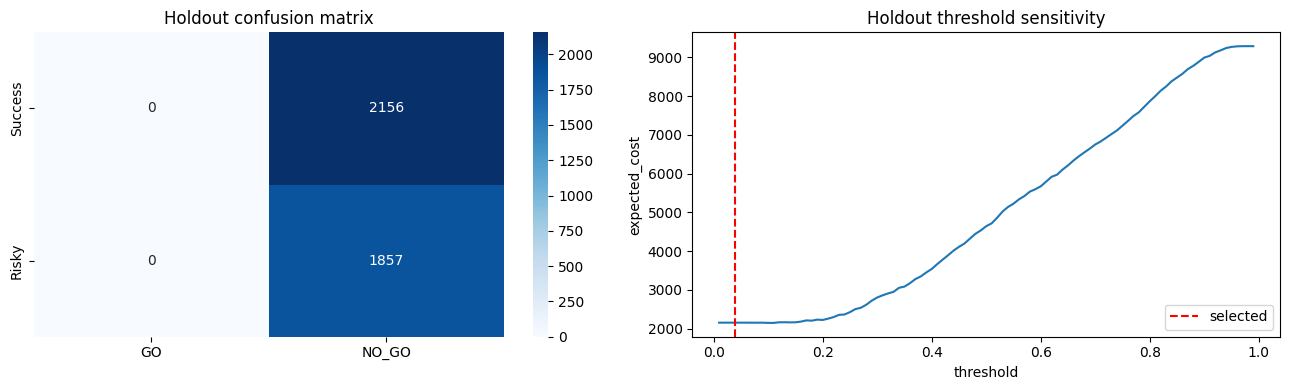

In [5]:
champion_name = comparison.iloc[0]["family"]
champion = trained[champion_name]
metrics = champion["metrics"]
threshold = metrics["threshold"]
print(f"champion={champion_name}; threshold={threshold:.2f}; cost={metrics['expected_cost']}; auc={metrics['roc_auc']:.4f}")

confusion = np.array([[metrics["true_negatives"], metrics["false_positives"]], [metrics["false_negatives"], metrics["true_positives"]]])
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues", xticklabels=["GO", "NO_GO"], yticklabels=["Success", "Risky"], ax=axes[0])
axes[0].set_title("Holdout confusion matrix")

threshold_rows = []
for index in range(1, 100):
    candidate = index / 100
    predictions = champion["probabilities"] >= candidate
    fn = int(((predictions == 0) & (y_test == 1)).sum())
    fp = int(((predictions == 1) & (y_test == 0)).sum())
    threshold_rows.append({"threshold": candidate, "expected_cost": fn * COST_RATIO + fp})
threshold_diagnostics = pd.DataFrame(threshold_rows)
sns.lineplot(data=threshold_diagnostics, x="threshold", y="expected_cost", ax=axes[1])
axes[1].axvline(threshold, color="red", linestyle="--", label="selected")
axes[1].legend()
axes[1].set_title("Holdout threshold sensitivity")
plt.tight_layout()

In [6]:
model = champion["model"]
if hasattr(model, "coef_"):
    values = model.coef_.reshape(-1)
else:
    values = model.feature_importances_
importance = pd.DataFrame({"feature": feature_list, "importance": values})
importance["absolute_importance"] = importance["importance"].abs()
importance = importance.sort_values("absolute_importance", ascending=False)
display(importance.head(20))

,feature,importance,absolute_importance
14,major_version_jump,0.105793,0.105793
17,core_system_touched,0.100706,0.100706
16,emergency_no_maintenance,0.049739,0.049739
0,version_jump_magnitude,0.040500,0.040500
3,protocol_mismatch_flag,0.037458,0.037458
82,deployment_type_EMERGENCY,0.032199,0.032199
12,cross_vendor_dependency_count,0.029257,0.029257
8,past_failure_count,0.020767,0.020767
1,kernel_touched,0.019178,0.019178
79,site_criticality_HIGH,0.016542,0.016542


## Persist the standalone research bundle and MLflow run

The preprocessor is a plain dictionary so notebook 5 can show every stored state element before applying it.

In [7]:
output_dir = ROOT / "notebook_runs" / "model"
output_dir.mkdir(parents=True, exist_ok=True)
timestamp = datetime.now(timezone.utc).isoformat().replace("+00:00", "Z")
metadata = {
    "model_name": champion_name,
    "params": champion["params"],
    "threshold": threshold,
    "cost_ratio_fn_fp": COST_RATIO,
    "cutoff_date": cutoff.isoformat(),
    "train_size": len(train_side),
    "test_size": len(test_side),
    "metrics": {row["family"]: {key: value for key, value in row.items() if key != "family"} for row in rows},
    "timestamp": timestamp,
    "source": "04_training_and_evaluation.ipynb",
}
preprocessor = {
    "categorical_columns": CATEGORICAL,
    "numeric_columns": MODEL_NUMERIC,
    "medians": medians.to_dict(),
    "encoder": encoder,
    "scaler": scaler,
    "feature_list": feature_list,
}
joblib.dump(model, output_dir / "model.joblib")
joblib.dump(preprocessor, output_dir / "preprocessor.joblib")
(output_dir / "metadata.json").write_text(json.dumps(metadata, indent=2, sort_keys=True) + "\n", encoding="utf-8")
comparison.to_csv(output_dir / "model_comparison.csv", index=False)
threshold_diagnostics.to_csv(output_dir / "threshold_diagnostics.csv", index=False)
importance.to_csv(output_dir / "feature_importance.csv", index=False)

tracking_dir = ROOT / "notebook_runs"
mlflow.set_tracking_uri(f"sqlite:///{(tracking_dir / 'notebook_mlflow.db').as_posix()}")
experiment_name = "firmaware-notebook"
experiment = mlflow.get_experiment_by_name(experiment_name)
if experiment is None:
    mlflow.create_experiment(experiment_name, artifact_location=(tracking_dir / "mlruns").resolve().as_uri())
mlflow.set_experiment(experiment_name)
with mlflow.start_run(run_name=f"notebook-{champion_name}") as run:
    mlflow.log_params({"model_name": champion_name, "threshold": threshold, **{key: "none" if value is None else value for key, value in champion["params"].items()}})
    mlflow.log_metrics({key: float(value) for key, value in metrics.items()})
    mlflow.log_artifacts(str(output_dir), artifact_path="research_bundle")
    metadata["mlflow_run_id"] = run.info.run_id
(output_dir / "metadata.json").write_text(json.dumps(metadata, indent=2, sort_keys=True) + "\n", encoding="utf-8")
print(output_dir)
print("MLflow run:", metadata["mlflow_run_id"])

2026/07/23 18:21:27 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/07/23 18:21:27 INFO mlflow.store.db.utils: Updating database tables


C:\Users\pmkul\Downloads\FirmAware\notebook_runs\model
MLflow run: 529a31e5776d4736ae15bf6fda9e3a7e
